In [ ]:
#####################
#Loading Packages and Reading Data

In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [2]:
if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    # variable='th'; th_data=data[variable].data # get qc data
    # variable='buoyancy'; buoyancy_data=data[variable].data # get qc data

    variable='rho'; rho_data=data[variable].data
    qt_data=qv_data+qc_data+qi_data+data['qr'].data+data['qs'].data+data['qg'].data
    print('done loading')
    emptylike=True

loading neccessary variables
done loading


In [3]:
#Make threshold binary array for cloudy updrafts
A=w_data.copy()
A[:]=0
w_thresh=0.1 #1 #m/s
qcqi_thresh=1e-6 #kg/kg
where=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqi_thresh))
A[where]=1

In [4]:
def avg(var): #TESTING***
    out=np.mean(var, axis=(2,3)) #takes horizontal average leaving (t,z)
    return out

def ddz(f):
    # f=f.data
    dz=data['zh'].values
    dz=dz.copy()[np.newaxis, :]
    
    _ddz=np.zeros_like(f)
    _ddz[:, 1:-1] = (f[:, 2:] - f[:, :-2]) / (2 * dz[:, 1:-1])
    _ddz[:, 0] = (f[:, 1] - f[:, 0]) / dz[:, 0]  # Forward difference 
    _ddz[:, -1] = (f[:, -1] - f[:, -2]) / dz[:, -1]  # Backward difference 
    return _ddz

def ddt(f):
    dt=(data['time'][1]-data['time'][0]).item()/1e9
    _ddt=np.zeros_like(f)
    _ddt[1:-1] = (f[2:] - f[:-2]) / (dt)
    return _ddt


In [31]:
def e_d(type):
    phi=qt_data #TESTING***
    phi_e=avg(phi*rho_data*(1-A))/avg(rho_data*(1-A)) #TESTING***
    phi_d=avg(phi*rho_data*w_data*A)/avg(rho_data*w_data*A) #TESTING***
    if type=='e':
        phi_e_d=phi_d
    elif type=='d':
        phi_e_d=phi_e

    RHS1 = ddt(avg(rho_data*A)) + ddz(avg(rho_data*w_data*A))
    RHS2 = ddt(avg(phi*rho_data*A)) + ddz(avg(phi*rho_data*w_data*A))
    RHS = (phi_e_d * RHS1) - RHS2
    RHS/=(phi_d-phi_e)
    
    return RHS

In [32]:
entrain=e_d('e')

detrain=e_d('d')

/tmp/ipykernel_785521/1661102415.py:4: RuntimeWarning: invalid value encountered in divide
  phi_d=avg(phi*rho_data*w_data*A)/avg(rho_data*w_data*A) #TESTING***
/tmp/ipykernel_785521/1661102415.py:4: RuntimeWarning: invalid value encountered in divide
  phi_d=avg(phi*rho_data*w_data*A)/avg(rho_data*w_data*A) #TESTING***


Text(0, 0.5, 'z level')

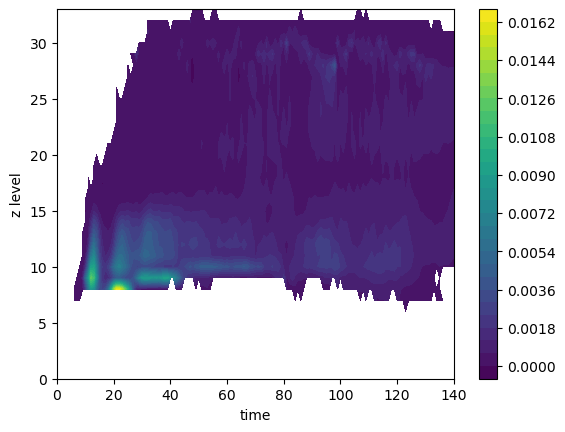

In [33]:
plt.contourf(entrain.T,levels=30)
plt.colorbar()
plt.xlabel('time');plt.ylabel('z level')

Text(0, 0.5, 'z level')

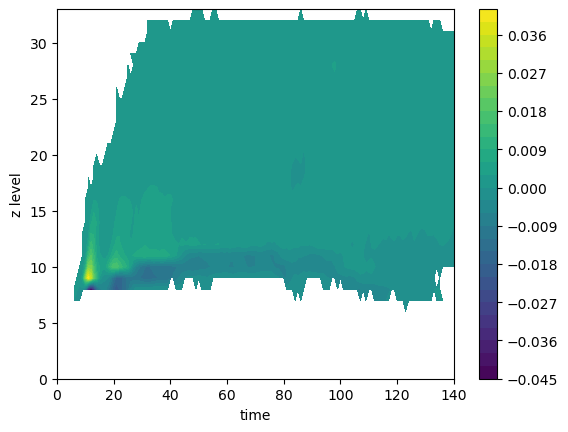

In [35]:
plt.contourf(detrain.T,levels=30)
plt.colorbar()
plt.xlabel('time');plt.ylabel('z level')




Text(0, 0.5, 'z level')

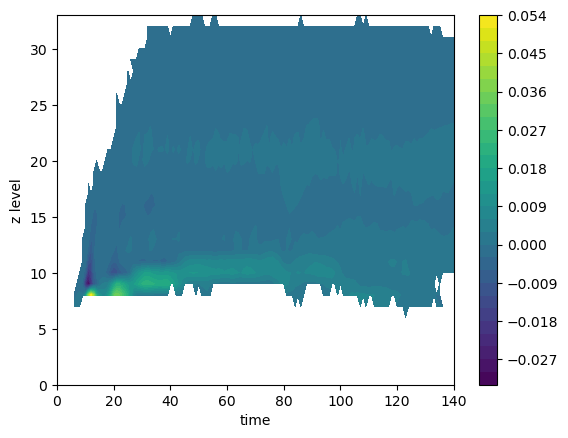

In [36]:
mixed=entrain-detrain
plt.contourf(mixed.T,levels=30)
plt.colorbar()
plt.xlabel('time');plt.ylabel('z level')

/tmp/ipykernel_785521/3665585070.py:1: RuntimeWarning: Mean of empty slice
  entrain_mean=np.nanmean(entrain,axis=0)
/tmp/ipykernel_785521/3665585070.py:4: RuntimeWarning: Mean of empty slice
  detrain_mean=np.nanmean(detrain,axis=0)


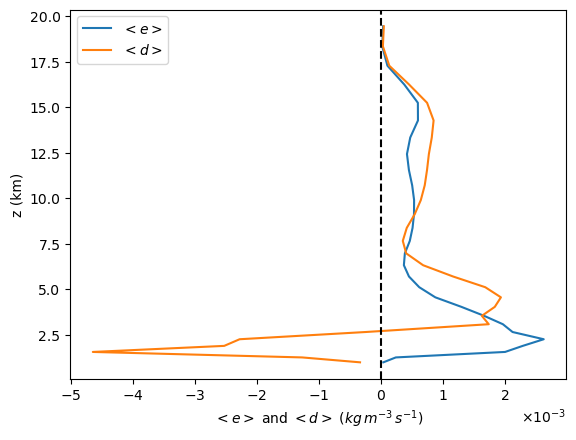

In [37]:
entrain_mean=np.nanmean(entrain,axis=0)
plt.plot(entrain_mean,data['zh'].values,label='$<e>$')

detrain_mean=np.nanmean(detrain,axis=0)
plt.plot(detrain_mean,data['zh'].values,label='$<d>$')
plt.axvline(0,color='k',linestyle='dashed')

plt.legend(loc='upper left')
plt.xlabel('$<e>$ and $<d>$ ($kg\,m^{-3}\,s^{-1}$)');plt.ylabel('z (km)')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
plt.gca().xaxis.set_major_formatter(formatter)  

/tmp/ipykernel_785521/1452357503.py:1: RuntimeWarning: Mean of empty slice
  mixed_mean=np.nanmean(entrain-detrain,axis=0)


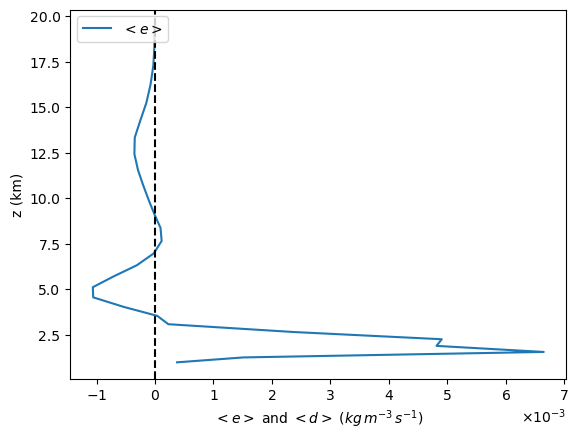

In [38]:
mixed_mean=np.nanmean(entrain-detrain,axis=0)
plt.plot(mixed_mean,data['zh'].values,label='$<e>$')
plt.axvline(0,color='k',linestyle='dashed')

plt.legend(loc='upper left')
plt.xlabel('$<e>$ and $<d>$ ($kg\,m^{-3}\,s^{-1}$)');plt.ylabel('z (km)')

from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
plt.gca().xaxis.set_major_formatter(formatter)  

Text(0.5, 0.98, 'Entrainment Diagnostic')

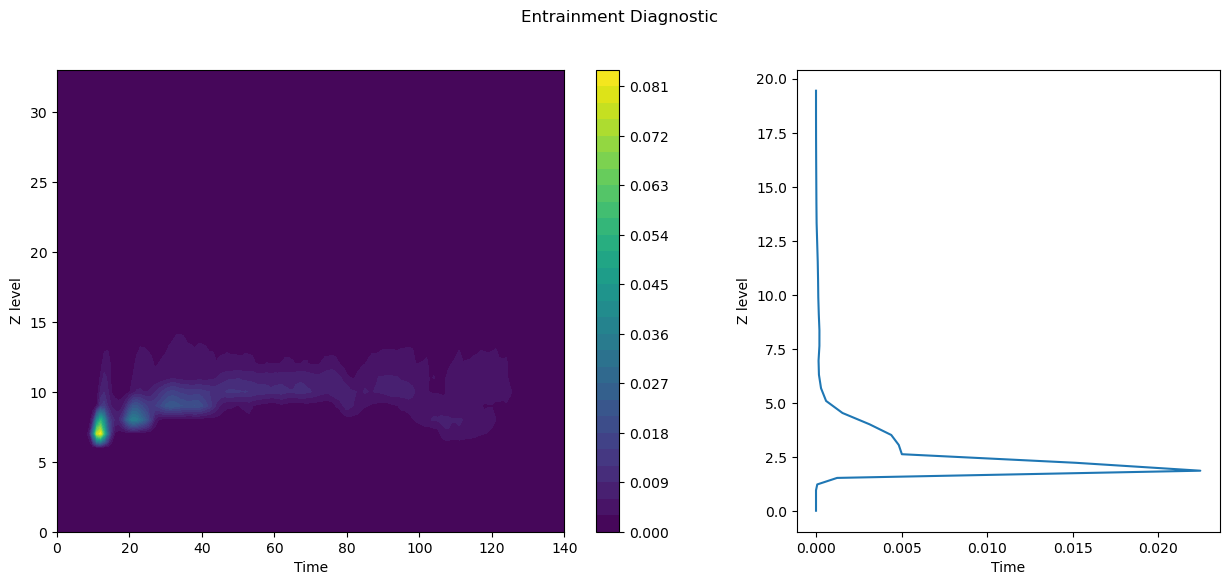

In [38]:
#DIAGNOSTIC
def ddz(f):
    # f=f.data
    dz=data['zh'].values
    dz=dz.copy()[np.newaxis, :, np.newaxis, np.newaxis]
    
    _ddz=np.zeros_like(f)
    _ddz[:, 1:-1, :, :] = (f[:, 2:, :, :] - f[:, :-2, :, :]) / (2 * dz[:, 1:-1])
    _ddz[:, 0, :, :] = (f[:, 1, :, :] - f[:, 0, :, :]) / dz[:, 0]  # Forward difference 
    _ddz[:, -1, :, :] = (f[:, -1, :, :] - f[:, -2, :, :]) / dz[:, -1]  # Backward difference 
    return _ddz

def ddy(f):
    # f=f.data
    dy=1000
    
    _ddy=np.zeros_like(f)
    _ddy[:, :, 1:-1, :] = (f[:, :, 2:, :] - f[:, :, :-2, :]) / (2 * dy)
    _ddy[:, :, 0, :] = (f[:, :, 1, :] - f[:, :, 0, :]) / dy  # Forward difference 
    _ddy[:, :, -1, :] = (f[:, :, -1, :] - f[:, :, -2, :]) / dy  # Backward difference 
    return _ddy

def ddx(f):
    # f=f.data
    dx=1000
    
    _ddx=np.zeros_like(f)
    _ddx[:, :, :, 1:-1] = (f[:, :, :, 2:] - f[:, :, :, :-2]) / (2 * dx)
    _ddx[:, :, :, 0] = (f[:, :, :, 1] - f[:, :, :, 0]) / dx  # Forward difference 
    _ddx[:, :, :, -1] = (f[:, :, :, -1] - f[:, :, :, -2]) / dx  # Backward difference 
    return _ddx

def div(f):
    _div=ddz(f)+ddy(f)+ddx(f)
    return _div

def e_d(type): #TESTING***

    if type=='e':
        RHS=ddt(rho_data*A)+div(rho_data*w_data*A)  
        # RHS=np.max(np.zeros_like(RHS),RHS)
        RHS[np.where(RHS<=0)]=0
    elif type=='d':
        RHS=-ddt(rho_data*A)-div(rho_data*w_data*A)
        # RHS=np.max(np.zeros_like(RHS),RHS)
        RHS[np.where(RHS<=0)]=0
    
    return RHS

entrain=e_d('e')
# detrain=e_d('d')


########################################################################
entrain_mean=np.mean(entrain,axis=(2,3))

import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(15, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])  # 1 row, 2 columns

# Create the first subplot (contour plot)
ax0 = fig.add_subplot(gs[0])
c = ax0.contourf(entrain_mean.T,levels=30)
fig.colorbar(c, ax=ax0)
ax0.set_xlabel('Time')
ax0.set_ylabel('Z level')

# Create the second subplot (line plot)
ax1 = fig.add_subplot(gs[1])
ax1.plot(entrain_mean[33], data['zh'].values)
ax1.set_xlabel('Time')
ax1.set_ylabel('Z level')

fig.suptitle('Entrainment Diagnostic')

Text(0.5, 0.98, 'Detrainment Diagnostic')

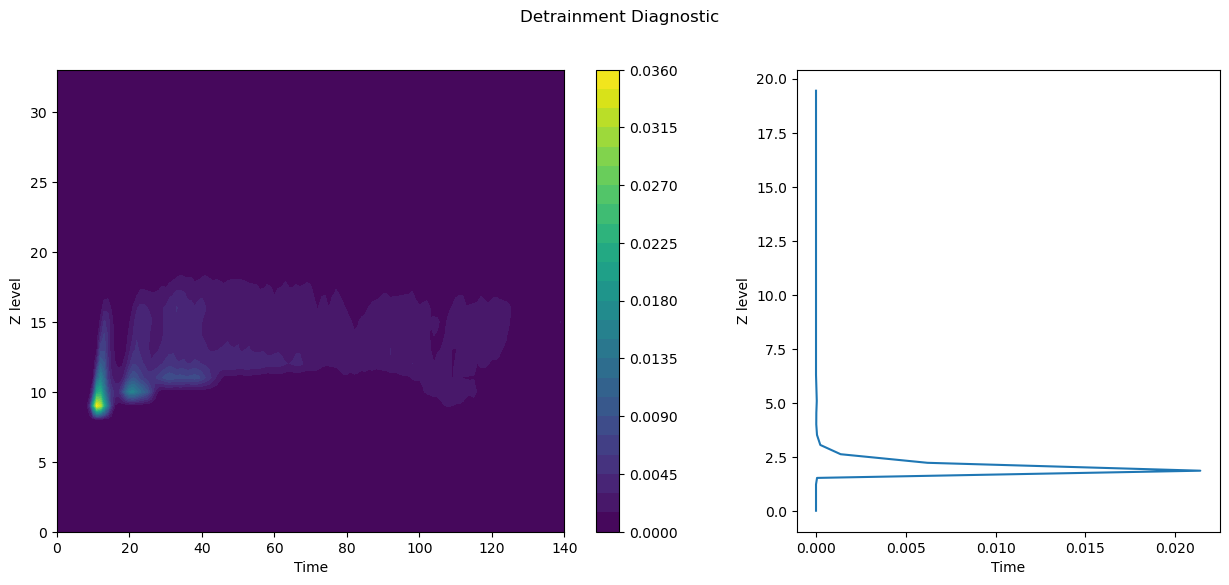

In [34]:
# detrain=e_d('d')

# detrain_mean=np.mean(detrain,axis=(2,3))


########################################################################
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(15, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])  # 1 row, 2 columns

# Create the first subplot (contour plot)
ax0 = fig.add_subplot(gs[0])
c = ax0.contourf(detrain_mean.T,levels=30)
fig.colorbar(c, ax=ax0)
ax0.set_xlabel('Time')
ax0.set_ylabel('Z level')

# Create the second subplot (line plot)
ax1 = fig.add_subplot(gs[1])
ax1.plot(detrain_mean[10], data['zh'].values)
ax1.set_xlabel('Time')
ax1.set_ylabel('Z level')

fig.suptitle('Detrainment Diagnostic')

Text(0.5, 0.98, 'Entrainment - Detrainment Diagnostic')

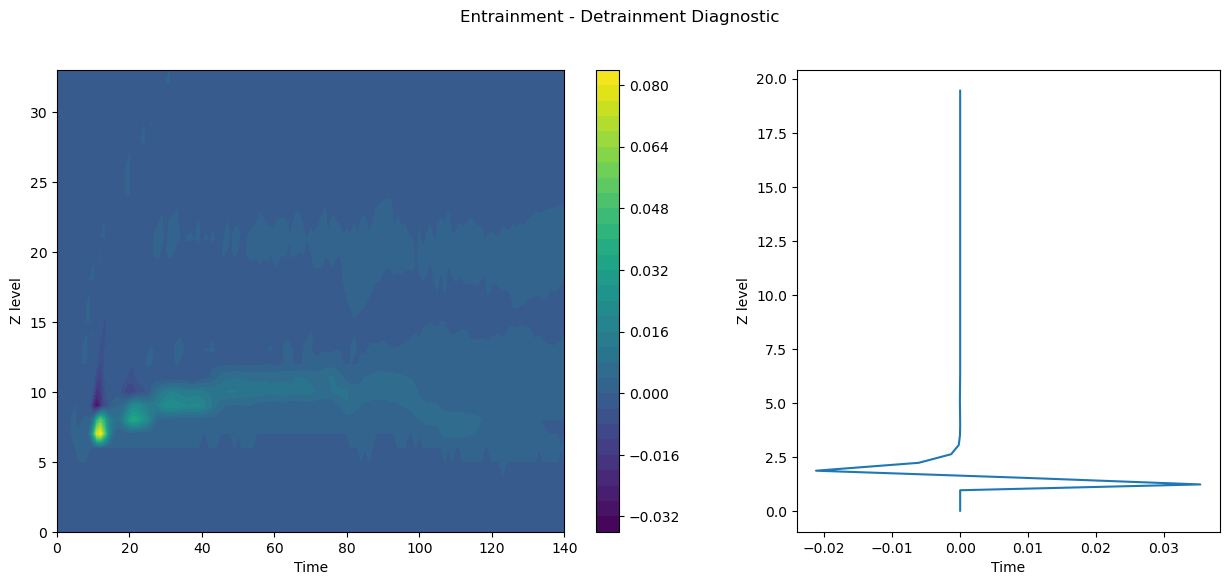

In [36]:
mixed=entrain_mean-detrain_mean

########################################################################
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])  # 1 row, 2 columns

# Create the first subplot (line plot)
ax0 = fig.add_subplot(gs[0])
c = ax0.contourf(mixed.T,levels=30)
fig.colorbar(c, ax=ax0)
ax0.set_xlabel('Time')
ax0.set_ylabel('Z level')

# Create the second subplot (line plot)
ax1 = fig.add_subplot(gs[1])
ax1.plot(mixed[10], data['zh'].values)
ax1.set_xlabel('Time')
ax1.set_ylabel('Z level')

fig.suptitle('Entrainment - Detrainment Diagnostic')